Random Seed: 999
Device: cuda:0
GPU: NVIDIA GeForce RTX 5070 Laptop GPU  torch.cuda: 13.0
OUT_DIR: ./cwgan_gp_mri_outputs\run_20260327_125132
Train classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Test  classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Using ALL classes. num_classes = 4
Using WeightedRandomSampler to balance classes.


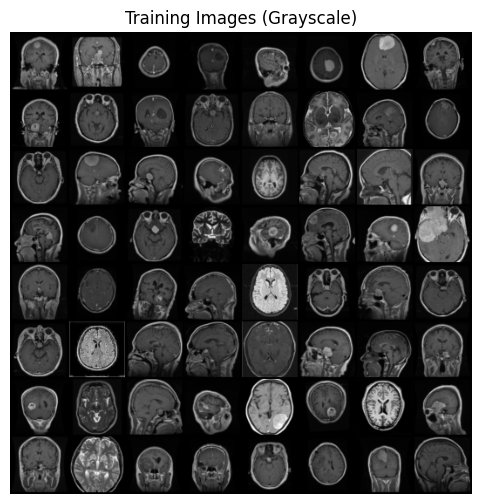

ConditionalGenerator(
  (embed): Embedding(4, 100)
  (de1): ConvTranspose2d(200, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
  (cbn1): ConditionalBatchNorm2d(
    (bn): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (embed): Embedding(4, 1024)
  )
  (de2): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (cbn2): ConditionalBatchNorm2d(
    (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (embed): Embedding(4, 512)
  )
  (de3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (cbn3): ConditionalBatchNorm2d(
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (embed): Embedding(4, 256)
  )
  (de4): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (cbn4): ConditionalBatchNorm2d(
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affin

c:\Users\22958\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


[TEST] epoch 1/40  mean D(real)=+7.028  mean D(fake)=-3.080
[FID ] epoch 1/40  FID=357.3783
[KID ] epoch 1/40  KID_mean=0.447569  KID_std=0.010058
[BEST] New best FID = 357.3783 at epoch 1
[2/40] iter   100  LossD=-12.2741 LossG=-13.7482  D(real)=+23.411 D(fake)=+9.010  GP=0.213
[TEST] epoch 2/40  mean D(real)=+14.895  mean D(fake)=+4.068
[FID ] epoch 2/40  FID=297.8208
[KID ] epoch 2/40  KID_mean=0.357399  KID_std=0.010856
[BEST] New best FID = 297.8208 at epoch 2
[3/40] iter   200  LossD=-12.6253 LossG=-5.6766  D(real)=+12.447 D(fake)=-1.980  GP=0.180
[TEST] epoch 3/40  mean D(real)=+12.184  mean D(fake)=-1.244
[FID ] epoch 3/40  FID=310.7924
[KID ] epoch 3/40  KID_mean=0.378063  KID_std=0.010320
[4/40] iter   300  LossD=-11.5039 LossG=6.9655  D(real)=+18.213 D(fake)=+3.545  GP=0.316
[TEST] epoch 4/40  mean D(real)=+5.999  mean D(fake)=-5.067
[FID ] epoch 4/40  FID=269.7346
[KID ] epoch 4/40  KID_mean=0.283681  KID_std=0.013288
[BEST] New best FID = 269.7346 at epoch 4
[5/40] iter   

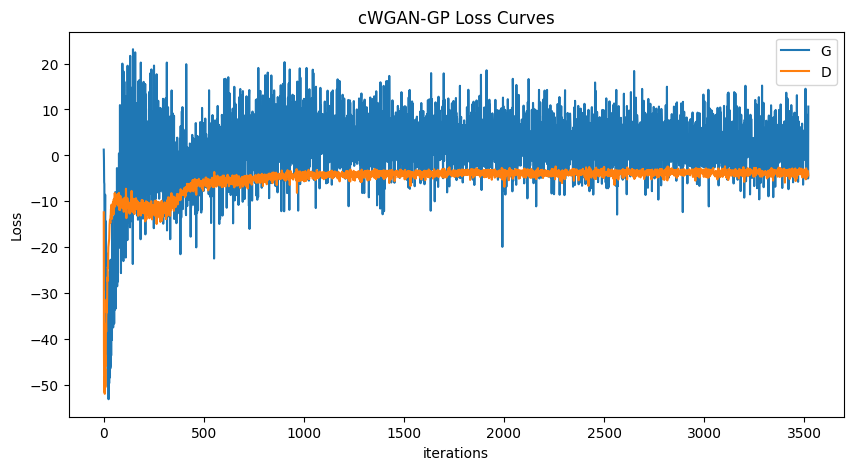

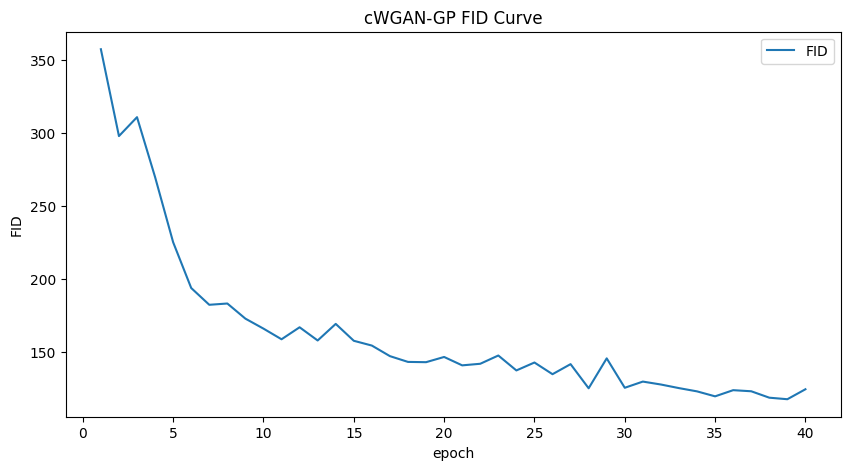

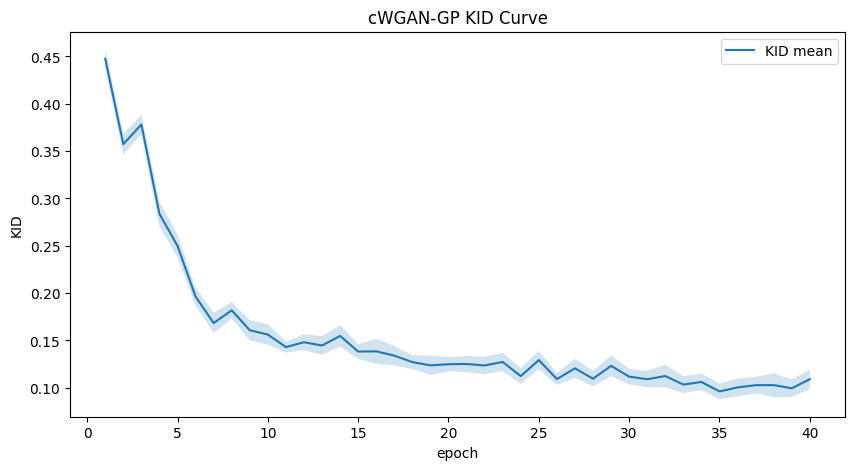

Done. Outputs saved to: ./cwgan_gp_mri_outputs\run_20260327_125132
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Best FID: 117.4065 at epoch 39
Loaded best-FID generator: ./cwgan_gp_mri_outputs\run_20260327_125132\netG_best_fid.pth


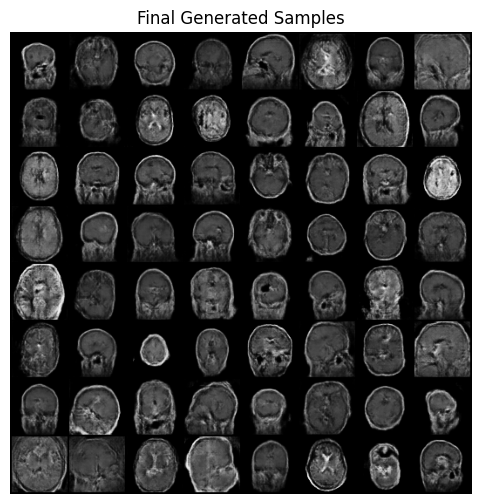

In [1]:
# ============================================================
# cWGAN-GP for Grayscale MRI 64x64 (ImageFolder)
# + FID + KID evaluation
# - G: z + y embedding + Conditional BatchNorm (cBN)
# - D: Projection Discriminator (no sigmoid)
# - Loss: Wasserstein + Gradient Penalty
# - Optional Step0: train only one class -> labels remap to 0, num_classes=1
# - Saves: fixed samples + random samples + checkpoints + metrics.csv
# ============================================================

import os
import time
import random
import csv
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, Subset, DataLoader, WeightedRandomSampler
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# ===== FID / KID =====
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.kid import KernelInceptionDistance
except ImportError as e:
    raise ImportError(
        "Missing packages. Please run:\n"
        "py -m pip install \"torchmetrics[image]\" torch-fidelity\n"
        "or:\n"
        "python -m pip install \"torchmetrics[image]\" torch-fidelity"
    ) from e

# -------------------------
# 0) Seed / device
# -------------------------
manualSeed = 999
print("Random Seed:", manualSeed)
random.seed(manualSeed)
np.random.seed(manualSeed)
torch.manual_seed(manualSeed)

torch.use_deterministic_algorithms(False)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0), " torch.cuda:", torch.version.cuda)

# -------------------------
# 1) Paths / output
# -------------------------
TRAIN_ROOT = r"C:\Users\22958\Desktop\毕业论文\archive\Training"
TEST_ROOT  = r"C:\Users\22958\Desktop\毕业论文\archive\Testing"

RUN_ID = time.strftime("run_%Y%m%d_%H%M%S")
OUT_DIR = os.path.join("./cwgan_gp_mri_outputs", RUN_ID)
os.makedirs(OUT_DIR, exist_ok=True)
print("OUT_DIR:", OUT_DIR)

# -------------------------
# 2) Hyperparameters
# -------------------------
workers = 0
batch_size = 64
image_size = 64
nc = 1
nz = 100
embed_dim = 100
ngf = 64
ndf = 64

num_epochs = 40
lrD = 1e-4
lrG = 2e-4
betas = (0.0, 0.9)

lambda_gp = 10.0
n_critic = 3
SAVE_EVERY_ITERS = 200

# Train mode:
TARGET_CLASS = None   # None / "notumor" / "glioma" / "meningioma" / "pituitary"
USE_BALANCED_SAMPLER = True

# Eval config:
MAX_EVAL_IMAGES = None    # None = use all test images; set 500/1000 for faster debugging
KID_SUBSET_SIZE = 50
KID_SUBSETS = 20
LABEL_MODE_FOR_EVAL = "match_real"   # "match_real" or "uniform"

# -------------------------
# 3) Dataset
# -------------------------
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_full = dset.ImageFolder(root=TRAIN_ROOT, transform=transform)
test_full  = dset.ImageFolder(root=TEST_ROOT,  transform=transform)

print("Train classes:", train_full.classes)
print("Test  classes:", test_full.classes)
assert train_full.classes == test_full.classes, "Train/Test class order mismatch!"
all_class_names = train_full.classes

class OneClassWrapper(Dataset):
    """Wrap dataset but force label to 0 (for single-class conditional training)."""
    def __init__(self, base_ds):
        self.base_ds = base_ds

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        x, _ = self.base_ds[idx]
        return x, 0

def filter_one_class(ds: dset.ImageFolder, class_name: str):
    idx = ds.class_to_idx[class_name]
    keep = [i for i, (_, y) in enumerate(ds.samples) if y == idx]
    return Subset(ds, keep)

if TARGET_CLASS is None:
    train_ds = train_full
    test_ds  = test_full
    num_classes = len(all_class_names)
    class_names = all_class_names
    print("Using ALL classes. num_classes =", num_classes)
else:
    train_sub = filter_one_class(train_full, TARGET_CLASS)
    test_sub  = filter_one_class(test_full,  TARGET_CLASS)
    train_ds = OneClassWrapper(train_sub)
    test_ds  = OneClassWrapper(test_sub)
    num_classes = 1
    class_names = [TARGET_CLASS]
    print(f"Filtered to '{TARGET_CLASS}' only. Train={len(train_ds)} Test={len(test_ds)} num_classes=1")

def extract_labels(ds):
    if isinstance(ds, dset.ImageFolder):
        return [y for _, y in ds.samples]
    if isinstance(ds, Subset) and isinstance(ds.dataset, dset.ImageFolder):
        base = ds.dataset
        return [base.samples[i][1] for i in ds.indices]
    return [ds[i][1] for i in range(len(ds))]

# Balanced sampler helps a lot for conditional training
if (TARGET_CLASS is None) and USE_BALANCED_SAMPLER:
    labels = np.array(extract_labels(train_ds), dtype=np.int64)
    counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
    counts[counts == 0] = 1.0
    weights = 1.0 / counts[labels]
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(weights, dtype=torch.double),
        num_samples=len(weights),
        replacement=True
    )
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=workers,
        pin_memory=(device.type == "cuda")
    )
    print("Using WeightedRandomSampler to balance classes.")
else:
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=workers,
        pin_memory=(device.type == "cuda")
    )

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=workers,
    pin_memory=(device.type == "cuda")
)

# -------------------------
# 4) Visualize a batch
# -------------------------
real_batch = next(iter(train_loader))
plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Training Images (Grayscale)")
grid = vutils.make_grid(real_batch[0][:64], padding=2, normalize=True)
plt.imshow(grid[0], cmap="gray")
plt.show()

# -------------------------
# 5) Conditional BatchNorm
# -------------------------
class ConditionalBatchNorm2d(nn.Module):
    """BN without affine + (gamma,beta) from label embedding."""
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.bn = nn.BatchNorm2d(num_features, affine=False)
        self.embed = nn.Embedding(num_classes, num_features * 2)
        self.num_features = num_features

        nn.init.zeros_(self.embed.weight.data)
        self.embed.weight.data[:, :num_features] = 1.0  # gamma=1

    def forward(self, x, y):
        out = self.bn(x)
        gb = self.embed(y)  # [B, 2C]
        gamma = gb[:, :self.num_features].view(-1, self.num_features, 1, 1)
        beta  = gb[:, self.num_features:].view(-1, self.num_features, 1, 1)
        return gamma * out + beta

# -------------------------
# 6) Models
# -------------------------
class ConditionalGenerator(nn.Module):
    def __init__(self, nz, embed_dim, ngf, nc, num_classes):
        super().__init__()
        self.embed = nn.Embedding(num_classes, embed_dim)
        in_ch = nz + embed_dim

        self.de1 = nn.ConvTranspose2d(in_ch, ngf * 8, 4, 1, 0, bias=False)
        self.cbn1 = ConditionalBatchNorm2d(ngf * 8, num_classes)

        self.de2 = nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False)
        self.cbn2 = ConditionalBatchNorm2d(ngf * 4, num_classes)

        self.de3 = nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False)
        self.cbn3 = ConditionalBatchNorm2d(ngf * 2, num_classes)

        self.de4 = nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False)
        self.cbn4 = ConditionalBatchNorm2d(ngf, num_classes)

        self.de5 = nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False)

        self.act = nn.ReLU(True)
        self.tanh = nn.Tanh()

    def forward(self, z, y):
        y_emb = self.embed(y).unsqueeze(2).unsqueeze(3)   # [B, embed_dim, 1, 1]
        x = torch.cat([z, y_emb], dim=1)                  # [B, nz+embed_dim, 1, 1]

        x = self.de1(x); x = self.cbn1(x, y); x = self.act(x)
        x = self.de2(x); x = self.cbn2(x, y); x = self.act(x)
        x = self.de3(x); x = self.cbn3(x, y); x = self.act(x)
        x = self.de4(x); x = self.cbn4(x, y); x = self.act(x)
        x = self.de5(x)
        return self.tanh(x)

class ProjectionDiscriminator(nn.Module):
    """
    D(x,y) = w^T h(x) + <E(y), h(x)>
    h(x): global sum pooled feature
    """
    def __init__(self, ndf, nc, num_classes):
        super().__init__()
        self.c1 = nn.Conv2d(nc, ndf, 4, 2, 1, bias=False)        # 64 -> 32
        self.c2 = nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)   # 32 -> 16
        self.c3 = nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False) # 16 -> 8
        self.c4 = nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False) # 8 -> 4

        self.act = nn.LeakyReLU(0.2, inplace=True)
        self.fc = nn.Linear(ndf * 8, 1)
        self.embed = nn.Embedding(num_classes, ndf * 8)

    def forward(self, x, y):
        h = self.act(self.c1(x))
        h = self.act(self.c2(h))
        h = self.act(self.c3(h))
        h = self.act(self.c4(h))       # [B, C, 4, 4]
        h = h.sum(dim=(2, 3))          # [B, C] global sum pooling

        out = self.fc(h).view(-1)      # [B]
        proj = (self.embed(y) * h).sum(dim=1)
        return out + proj

def weights_init(m):
    cname = m.__class__.__name__
    if "Conv" in cname or "Linear" in cname:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
    if "BatchNorm" in cname:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

netG = ConditionalGenerator(
    nz=nz, embed_dim=embed_dim, ngf=ngf, nc=nc, num_classes=num_classes
).to(device)

netD = ProjectionDiscriminator(
    ndf=ndf, nc=nc, num_classes=num_classes
).to(device)

netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)

optimizerG = optim.Adam(netG.parameters(), lr=lrG, betas=betas)
optimizerD = optim.Adam(netD.parameters(), lr=lrD, betas=betas)

# -------------------------
# 7) Gradient penalty
# -------------------------
def gradient_penalty(netD, real, fake, y, device):
    b = real.size(0)
    eps = torch.rand(b, 1, 1, 1, device=device)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)

    d_hat = netD(x_hat, y)
    grad = torch.autograd.grad(
        outputs=d_hat.sum(),
        inputs=x_hat,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    grad = grad.view(b, -1)
    gp = ((grad.norm(2, dim=1) - 1) ** 2).mean()
    return gp

# -------------------------
# 8) Fixed sampling
# -------------------------
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

if num_classes == 1:
    fixed_labels = torch.zeros(64, dtype=torch.long, device=device)
else:
    # 8x8 grid: each row uses one class id
    fixed_labels = torch.tensor(
        [r % num_classes for r in range(8) for _ in range(8)],
        dtype=torch.long,
        device=device
    )

@torch.no_grad()
def save_samples(tag):
    netG.eval()

    fake_fixed = netG(fixed_noise, fixed_labels).detach().cpu()

    z = torch.randn(64, nz, 1, 1, device=device)
    if num_classes == 1:
        y = torch.zeros(64, dtype=torch.long, device=device)
    else:
        y = torch.randint(0, num_classes, (64,), device=device)

    fake_rand = netG(z, y).detach().cpu()

    vutils.save_image(
        fake_fixed,
        os.path.join(OUT_DIR, f"{tag}_fixed.png"),
        normalize=True,
        nrow=8
    )
    vutils.save_image(
        fake_rand,
        os.path.join(OUT_DIR, f"{tag}_rand.png"),
        normalize=True,
        nrow=8
    )

    netG.train()

@torch.no_grad()
def test_sanity():
    # mean D(real,y) vs mean D(fake,y) on test
    netG.eval()
    netD.eval()

    real_scores, fake_scores = [], []

    for real, y in test_loader:
        real = real.to(device)
        y = y.to(device).long()
        b = real.size(0)

        z = torch.randn(b, nz, 1, 1, device=device)
        fake = netG(z, y)

        real_scores.append(netD(real, y).mean().item())
        fake_scores.append(netD(fake, y).mean().item())

    netG.train()
    netD.train()

    return float(np.mean(real_scores)), float(np.mean(fake_scores))

# -------------------------
# 8.5) FID / KID helpers
# -------------------------
def to_metric_input(x):
    """
    x: tensor in [-1,1], shape [B,1,H,W] or [B,3,H,W]
    return: float32 tensor in [0,1], 3-channel
    """
    x = x.detach().clamp(-1, 1)
    x = (x + 1.0) / 2.0

    if x.size(1) == 1:
        x = x.repeat(1, 3, 1, 1)

    return x.float()

def build_fid_metric(device):
    fid = FrechetInceptionDistance(
        feature=2048,
        reset_real_features=True,
        normalize=True
    ).to(device)
    return fid

def build_kid_metric(device, subset_size=50, subsets=20):
    subset_size = max(2, int(subset_size))
    kid = KernelInceptionDistance(
        feature=2048,
        subsets=subsets,
        subset_size=subset_size,
        reset_real_features=True,
        normalize=True
    ).to(device)
    return kid

@torch.no_grad()
def compute_fid_kid_cwgan(
    netG,
    test_loader,
    device,
    nz,
    num_classes,
    max_images=None,
    label_mode="match_real",
    kid_subset_size=50,
    kid_subsets=20
):
    netG.eval()

    test_size = len(test_loader.dataset)
    effective_eval_n = test_size if max_images is None else min(test_size, max_images)
    effective_kid_subset_size = min(kid_subset_size, max(2, effective_eval_n))

    fid = build_fid_metric(device)
    kid = build_kid_metric(
        device,
        subset_size=effective_kid_subset_size,
        subsets=kid_subsets
    )

    seen = 0

    for real, y_real in test_loader:
        real = real.to(device)
        y_real = y_real.to(device).long()
        b = real.size(0)

        if max_images is not None and seen + b > max_images:
            keep = max_images - seen
            if keep <= 0:
                break
            real = real[:keep]
            y_real = y_real[:keep]
            b = keep

        real_in = to_metric_input(real)
        fid.update(real_in, real=True)
        kid.update(real_in, real=True)

        z = torch.randn(b, nz, 1, 1, device=device)

        if num_classes == 1:
            y_fake = torch.zeros(b, dtype=torch.long, device=device)
        else:
            if label_mode == "match_real":
                y_fake = y_real
            elif label_mode == "uniform":
                y_fake = torch.randint(0, num_classes, (b,), device=device)
            else:
                raise ValueError("label_mode must be 'match_real' or 'uniform'")

        fake = netG(z, y_fake)
        fake_in = to_metric_input(fake)

        fid.update(fake_in, real=False)
        kid.update(fake_in, real=False)

        seen += b

    fid_score = fid.compute().item()

    if effective_eval_n < 2:
        kid_mean, kid_std = float("nan"), float("nan")
    else:
        kid_mean_t, kid_std_t = kid.compute()
        kid_mean, kid_std = kid_mean_t.item(), kid_std_t.item()

    netG.train()
    return fid_score, kid_mean, kid_std

def save_metrics_csv(records, out_path):
    fieldnames = ["epoch", "test_D_real", "test_D_fake", "FID", "KID_mean", "KID_std"]
    with open(out_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(records)

# -------------------------
# 9) Train
# -------------------------
G_losses, D_losses = [], []
FID_scores = []
KID_means = []
KID_stds = []
epoch_records = []

best_fid = float("inf")
best_epoch = -1
iters = 0

print("Starting Training Loop...")
save_samples("init")

for epoch in range(num_epochs):
    for real, y_real in train_loader:
        real = real.to(device)
        y_real = y_real.to(device).long()
        b = real.size(0)

        # ----- Critic n_critic steps -----
        for _ in range(n_critic):
            z = torch.randn(b, nz, 1, 1, device=device)
            fake = netG(z, y_real).detach()

            d_real = netD(real, y_real)
            d_fake = netD(fake, y_real)

            gp = gradient_penalty(netD, real, fake, y_real, device)
            lossD = d_fake.mean() - d_real.mean() + lambda_gp * gp

            optimizerD.zero_grad(set_to_none=True)
            lossD.backward()
            optimizerD.step()

        # ----- Generator 1 step -----
        if num_classes == 1:
            y_g = torch.zeros(b, dtype=torch.long, device=device)
        else:
            y_g = torch.randint(0, num_classes, (b,), device=device)

        z = torch.randn(b, nz, 1, 1, device=device)
        fake = netG(z, y_g)
        lossG = -netD(fake, y_g).mean()

        optimizerG.zero_grad(set_to_none=True)
        lossG.backward()
        optimizerG.step()

        D_losses.append(lossD.item())
        G_losses.append(lossG.item())

        if iters % 100 == 0:
            print(
                f"[{epoch+1}/{num_epochs}] iter {iters:5d}  "
                f"LossD={lossD.item():.4f} LossG={lossG.item():.4f}  "
                f"D(real)={d_real.mean().item():+.3f} D(fake)={d_fake.mean().item():+.3f}  "
                f"GP={gp.item():.3f}"
            )

        if iters % SAVE_EVERY_ITERS == 0:
            save_samples(f"e{epoch+1}_i{iters}")

        iters += 1

    # ----- Epoch-level evaluation -----
    rmean, fmean = test_sanity()

    fid_score, kid_mean, kid_std = compute_fid_kid_cwgan(
        netG=netG,
        test_loader=test_loader,
        device=device,
        nz=nz,
        num_classes=num_classes,
        max_images=MAX_EVAL_IMAGES,
        label_mode=LABEL_MODE_FOR_EVAL,
        kid_subset_size=KID_SUBSET_SIZE,
        kid_subsets=KID_SUBSETS
    )

    FID_scores.append(fid_score)
    KID_means.append(kid_mean)
    KID_stds.append(kid_std)

    epoch_record = {
        "epoch": epoch + 1,
        "test_D_real": rmean,
        "test_D_fake": fmean,
        "FID": fid_score,
        "KID_mean": kid_mean,
        "KID_std": kid_std
    }
    epoch_records.append(epoch_record)
    save_metrics_csv(epoch_records, os.path.join(OUT_DIR, "metrics.csv"))

    print(f"[TEST] epoch {epoch+1}/{num_epochs}  mean D(real)={rmean:+.3f}  mean D(fake)={fmean:+.3f}")
    print(f"[FID ] epoch {epoch+1}/{num_epochs}  FID={fid_score:.4f}")
    print(f"[KID ] epoch {epoch+1}/{num_epochs}  KID_mean={kid_mean:.6f}  KID_std={kid_std:.6f}")

    # Save regular checkpoints
    torch.save(netG.state_dict(), os.path.join(OUT_DIR, f"netG_epoch{epoch+1}.pth"))
    torch.save(netD.state_dict(), os.path.join(OUT_DIR, f"netD_epoch{epoch+1}.pth"))

    # Save best-FID checkpoint
    if fid_score < best_fid:
        best_fid = fid_score
        best_epoch = epoch + 1
        torch.save(netG.state_dict(), os.path.join(OUT_DIR, "netG_best_fid.pth"))
        torch.save(netD.state_dict(), os.path.join(OUT_DIR, "netD_best_fid.pth"))
        print(f"[BEST] New best FID = {best_fid:.4f} at epoch {best_epoch}")

# -------------------------
# 10) Plot Loss
# -------------------------
plt.figure(figsize=(10, 5))
plt.title("cWGAN-GP Loss Curves")
plt.plot(range(1, len(G_losses) + 1), G_losses, label="G")
plt.plot(range(1, len(D_losses) + 1), D_losses, label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -------------------------
# 11) Plot FID
# -------------------------
plt.figure(figsize=(10, 5))
plt.title("cWGAN-GP FID Curve")
plt.plot(range(1, len(FID_scores) + 1), FID_scores, label="FID")
plt.xlabel("epoch")
plt.ylabel("FID")
plt.legend()
plt.show()

# -------------------------
# 12) Plot KID
# -------------------------
epochs_axis = np.arange(1, len(KID_means) + 1)
kid_means_np = np.array(KID_means)
kid_stds_np = np.array(KID_stds)

plt.figure(figsize=(10, 5))
plt.title("cWGAN-GP KID Curve")
plt.plot(epochs_axis, kid_means_np, label="KID mean")
plt.fill_between(
    epochs_axis,
    kid_means_np - kid_stds_np,
    kid_means_np + kid_stds_np,
    alpha=0.2
)
plt.xlabel("epoch")
plt.ylabel("KID")
plt.legend()
plt.show()

print("Done. Outputs saved to:", OUT_DIR)
print("Class names:", class_names)
print(f"Best FID: {best_fid:.4f} at epoch {best_epoch}")

# -------------------------
# 13) Show final samples from best-FID generator
# -------------------------
best_g_path = os.path.join(OUT_DIR, "netG_best_fid.pth")
if os.path.exists(best_g_path):
    netG.load_state_dict(torch.load(best_g_path, map_location=device))
    print("Loaded best-FID generator:", best_g_path)
else:
    print("Best-FID checkpoint not found, using current netG.")

@torch.no_grad()
def show_grid_cdcgan(netG, nz, device, num_classes, n=64):
    netG.eval()
    z = torch.randn(n, nz, 1, 1, device=device)
    y = torch.randint(0, num_classes, (n,), device=device)
    fake = netG(z, y).cpu()

    grid = vutils.make_grid(fake, nrow=8, normalize=True)
    plt.figure(figsize=(6, 6))
    plt.axis("off")
    plt.title("Final Generated Samples")
    plt.imshow(grid[0], cmap="gray")
    plt.show()

show_grid_cdcgan(netG, nz, device, num_classes)

In [2]:
print("Done. Outputs saved to:", OUT_DIR)
print("Class names:", class_names)
print(f"Best FID: {best_fid:.4f} at epoch {best_epoch}")

best_fid_idx = best_epoch - 1
if 0 <= best_fid_idx < len(KID_means):
    print(f"KID at best-FID epoch: {KID_means[best_fid_idx]:.6f} ± {KID_stds[best_fid_idx]:.6f}")

best_kid_idx = int(np.nanargmin(KID_means))
print(f"Best KID: {KID_means[best_kid_idx]:.6f} ± {KID_stds[best_kid_idx]:.6f} at epoch {best_kid_idx+1}")

Done. Outputs saved to: ./cwgan_gp_mri_outputs\run_20260327_125132
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Best FID: 117.4065 at epoch 39
KID at best-FID epoch: 0.099445 ± 0.009450
Best KID: 0.096178 ± 0.008278 at epoch 35
